<a href="https://colab.research.google.com/github/ud-shalom/DecodeLabs-Internship/blob/main/AAPL_Stock_Analysis_AnalystLabAfrica_Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA LOADING**

In [1]:
!pip install yfinance -q
import yfinance as yf

# This downloads the last 5 years of AAPL data
df = yf.download("AAPL", period="5y")

# This shows you the first few rows so you know it worked
df.head()

/tmp/ipykernel_1731/3668824376.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", period="5y")
ERROR:yfinance:Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL: no alternative certificate subject name matches target hostname 'fc.yahoo.com'. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-07-08,139.623474,140.422763,137.118354,138.005382,105575500
2021-07-09,141.446259,141.972618,139.048362,139.145843,99890800
2021-07-12,140.851669,142.625725,140.364293,142.518502,76299700
2021-07-13,141.962891,143.736947,140.003644,140.393539,100827100
2021-07-14,145.384216,145.793625,143.951330,144.360739,127050800


In [11]:
# Import the necessary tool
import yfinance as yf

# 1. Download the data
df = yf.download("AAPL", period="5y")

# 2. Verify the Date is recognized as the index
# The index is the "anchor" for your data
print("The index of this data is:", df.index.name)

# 3. Show the final clean table
print("\nHere is your data:")
print(df.head())

/tmp/ipykernel_1731/111177820.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", period="5y")
[*********************100%***********************]  1 of 1 completed

The index of this data is: Date

Here is your data:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-07-08  139.623489  140.422778  137.118369  138.005397  105575500
2021-07-09  141.446274  141.972633  139.048377  139.145858   99890800
2021-07-12  140.851608  142.625663  140.364232  142.518440   76299700
2021-07-13  141.962845  143.736900  140.003599  140.393494  100827100
2021-07-14  145.384232  145.793640  143.951345  144.360754  127050800


In [3]:
# This will create a file named 'aapl_data.csv' that you CAN see in the Files tab
df.to_csv("aapl_data.csv")

**DATA EXPLORATION**

In [4]:
print(df.shape)

(1254, 5)


In [10]:
print(df.head())


Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-07-08  139.623505  140.422794  137.118384  138.005412  105575500
2021-07-09  141.446274  141.972633  139.048377  139.145858   99890800
2021-07-12  140.851639  142.625694  140.364263  142.518471   76299700
2021-07-13  141.962860  143.736916  140.003614  140.393509  100827100
2021-07-14  145.384232  145.793640  143.951345  144.360754  127050800


**DATA CLEANING AND PROCESSING**

In [ ]:
# Check for missing values in each column
print(df.isnull().sum())

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [7]:
# Check for duplicate dates in the index
duplicate_dates = df.index.duplicated().sum()

# Check for duplicate rows in the entire table
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate dates: {duplicate_dates}")
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate dates: 0
Number of duplicate rows: 0


**DATA TRANSFORMATION USING PANDAS**

In [ ]:
# 1. Flatten the column names (This fixes the "Multi-level" error)
df.columns = df.columns.get_level_values(0)

# 2. WHERE (Filtering): Only show days where 'Close' price is above 150
where_filter = df[df['Close'] > 150]

# 3. ORDER BY (Sorting): Sort by 'Volume' from highest to lowest
order_by = df.sort_values(by='Volume', ascending=False)

# 4. GROUP BY (Grouping): Group by Year and find the average 'Close' price
# First, we ensure the index (Date) is used to extract the Year
df['Year'] = df.index.year
group_by = df.groupby('Year')['Close'].mean()

# 5. Print all results to verify
print("--- WHERE Result (Top 5 rows where Close > 150) ---")
print(where_filter.head())

print("\n--- ORDER BY Result (Top 5 highest Volume days) ---")
print(order_by.head())

print("\n--- GROUP BY Result (Average Close Price per Year) ---")
print(group_by)

--- WHERE Result (Top 5 rows where Close > 150) ---
Price            Close        High         Low        Open    Volume
Date                                                                
2021-09-03  150.629562  150.951714  149.448339  150.102399  57808700
2021-09-07  152.962753  153.519187  150.717461  151.283666  82278300
2021-09-08  151.420288  153.304371  150.317163  153.245800  74420200
2021-09-09  150.405060  152.396527  150.287904  151.791280  57305700
2021-11-17  150.057526  151.533752  147.613433  147.623204  88807000

--- ORDER BY Result (Top 5 highest Volume days) ---
Price            Close        High         Low        Open     Volume
Date                                                                 
2024-09-20  226.502090  231.355706  225.926404  228.258925  318679900
2026-06-26  283.779999  285.950012  274.209991  275.000000  261775500
2024-06-21  205.708069  210.070275  205.331327  208.583157  241805100
2024-06-12  211.240158  218.308915  205.123133  205.589098  19

In [14]:
# 1. Flatten the column headers to fix the Multi-level error
df.columns = df.columns.get_level_values(0)

# 2. Ensure 'Year' is ready for grouping
df['Year'] = df.index.year

# 3. Perform the aggregation
yearly_stats = df.groupby('Year').agg({
    'Volume': 'sum',
    'Close': 'mean'
})

# 4. Rename columns for clarity
yearly_stats = yearly_stats.rename(columns={
    'Volume': 'Total_Volume',
    'Close': 'Average_Close_Price'
})

# 5. Display the final result
print("--- Yearly Performance Summary ---")
print(yearly_stats)

--- Yearly Performance Summary ---
Price  Total_Volume  Average_Close_Price
Year                                    
2021    10534856100           149.404953
2022    22065504500           151.805451
2023    14805886900           170.194612
2024    14390908500           205.457394
2025    13543944600           231.349891
2026     6443787901           274.349373


**YEARLY DATA AGGREGATION AND SUMMARY**

In [ ]:
# 1. First, simplify your columns
df.columns = df.columns.get_level_values(0)

# 2. Add your Feature Engineering columns (so we can aggregate them too)
df['Daily Price Change'] = df['Close'] - df['Open']
df['Percentage Change'] = ((df['Close'] - df['Open']) / df['Open']) * 100

# 3. Create the 'Year' column for grouping
df['Year'] = df.index.year

# 4. Perform comprehensive Aggregation
# We use 'mean' for prices and 'sum' for Volume/Change to make sense of the data
yearly_summary = df.groupby('Year').agg({
    'Open': 'mean',
    'High': 'mean',
    'Low': 'mean',
    'Close': 'mean',
    'Daily Price Change': 'sum',
    'Percentage Change': 'mean',
    'Volume': 'sum'
})

# 5. Rename columns for a professional summary table
yearly_summary = yearly_summary.rename(columns={
    'Open': 'Avg_Open',
    'High': 'Avg_High',
    'Low': 'Avg_Low',
    'Close': 'Avg_Close',
    'Daily Price Change': 'Total_Price_Change',
    'Percentage Change': 'Avg_Percentage_Change',
    'Volume': 'Total_Volume'
})

# 6. Display the final summary table
print("--- COMPREHENSIVE YEARLY AGGREGATION SUMMARY ---")
print(yearly_summary)

--- COMPREHENSIVE YEARLY AGGREGATION SUMMARY ---
Price    Avg_Open    Avg_High     Avg_Low   Avg_Close  Total_Price_Change  \
Year                                                                        
2021   149.065779  150.670584  147.781847  149.337076           33.912134   
2022   151.773848  153.837703  149.703617  151.805450            7.932149   
2023   169.906603  171.484991  168.649333  170.194612           72.002276   
2024   205.205687  207.147183  203.484609  205.457393           63.429815   
2025   231.156008  233.833558  228.745397  231.349892           48.470952   
2026   273.637641  276.879073  270.740024  273.792260           19.482035   

Price  Avg_Percentage_Change  Total_Volume  
Year                                        
2021                0.187320   10639767700  
2022                0.039063   22065504500  
2023                0.189365   14805886900  
2024                0.120553   14390908500  
2025                0.103553   13543944600  
2026               

**TIME-SERIES ANALYSIS**

In [ ]:
# --- TIME-SERIES ANALYSIS: EXTRACTION & TREND ANALYSIS ---

# 1. Extract Date Components
df["Year"] = df.index.year
df["Month"] = df.index.month_name()
df["Day"] = df.index.day

# 2. Average Closing Price by Year
avg_close_by_year = df.groupby("Year")["Close"].mean()

# 3. Average Volume by Year
avg_volume_by_year = df.groupby("Year")["Volume"].mean()

# Display results
print("--- UPDATED DATA WITH DATE COMPONENTS ---")
print(df.head())
print("\n--- AVERAGE CLOSING PRICE BY YEAR ---")
print(avg_close_by_year)
print("\n--- AVERAGE VOLUME BY YEAR ---")
print(avg_volume_by_year)

--- UPDATED DATA WITH DATE COMPONENTS ---
Price            Close        High         Low        Open     Volume  \
Date                                                                    
2021-07-07  140.919891  141.231804  139.058112  139.915883  104911600   
2021-07-08  139.623474  140.422763  137.118354  138.005382  105575500   
2021-07-09  141.446243  141.972603  139.048347  139.145828   99890800   
2021-07-12  140.851685  142.625741  140.364308  142.518517   76299700   
2021-07-13  141.962860  143.736916  140.003614  140.393509  100827100   

Price       Daily Price Change  Percentage Change  Year  7-Day MA  30-Day MA  \
Date                                                                           
2021-07-07            1.004008           0.717580  2021       NaN        NaN   
2021-07-08            1.618092           1.172485  2021       NaN        NaN   
2021-07-09            2.300415           1.653240  2021       NaN        NaN   
2021-07-12           -1.666833          -1.169

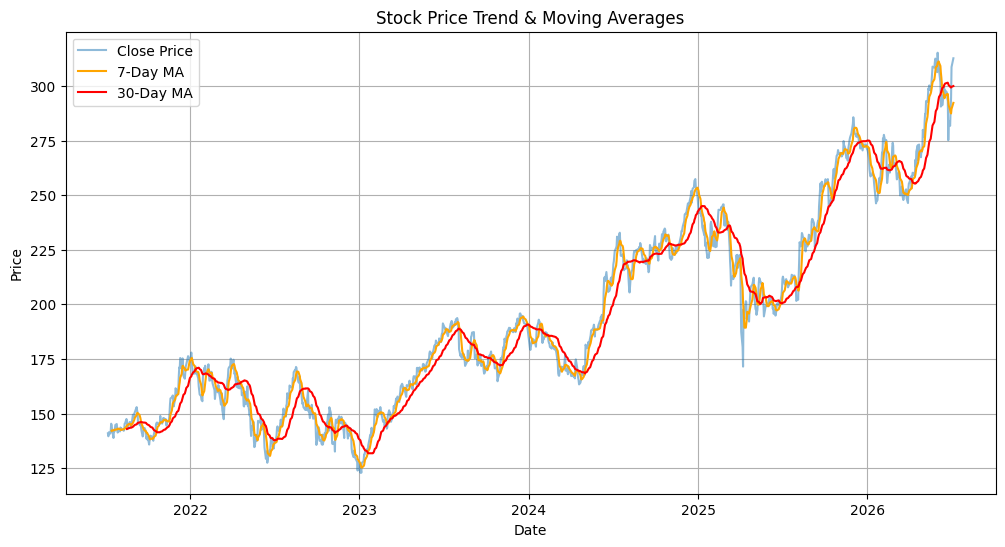

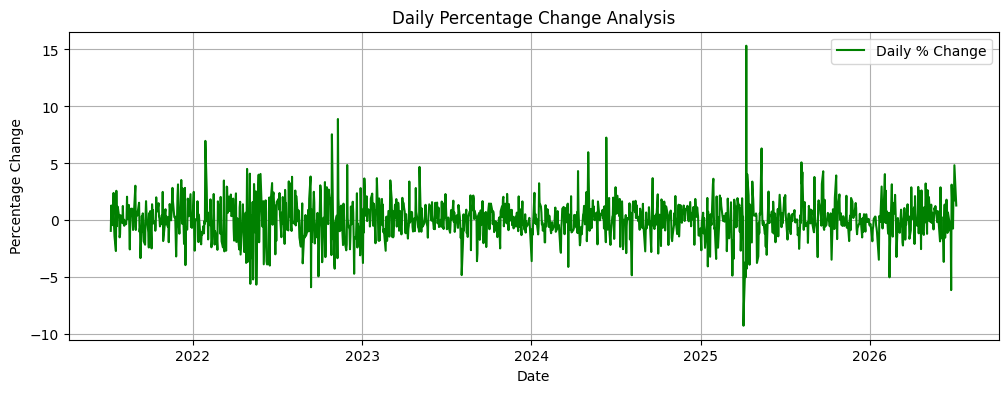

In [ ]:
import matplotlib.pyplot as plt

# --- 1. FEATURE ENGINEERING: Rolling Averages & % Change ---
df['7-Day MA'] = df['Close'].rolling(window=7).mean()
df['30-Day MA'] = df['Close'].rolling(window=30).mean()
df['Percentage Change'] = df['Close'].pct_change() * 100

# --- 2. VISUALIZATION ---

# A: Stock Price & Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.5)
plt.plot(df.index, df['7-Day MA'], label='7-Day MA', color='orange')
plt.plot(df.index, df['30-Day MA'], label='30-Day MA', color='red')
plt.title('Stock Price Trend & Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# B: Daily Percentage Change
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Percentage Change'], color='green', label='Daily % Change')
plt.title('Daily Percentage Change Analysis')
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.grid(True)
plt.legend()
plt.show()

**FEATURE ENGINERRING: CALCULATED NEW COLUMNS**

In [ ]:
# --- FEATURE ENGINEERING: CALCULATED NEW COLUMNS ---

# 1. Daily Price Change
df["Daily Price Change"] = df["Close"] - df["Open"]

# 2. Percentage Price Change
df["Percentage Change"] = ((df["Close"] - df["Open"]) / df["Open"]) * 100

# 3. 7-Day Moving Average
df["7-Day MA"] = df["Close"].rolling(window=7).mean()

# 4. 30-Day Moving Average
df["30-Day MA"] = df["Close"].rolling(window=30).mean()

# 5. Daily Return
df["Daily Return"] = df["Close"].pct_change()

# 6. Monthly Return (calculated separately as it resamples the time frequency)
monthly_return = df["Close"].resample("M").last().pct_change()

# 7. Volatility (30-day rolling standard deviation of daily returns)
df["Volatility"] = df["Daily Return"].rolling(window=30).std()

# Display the updated columns to verify the work
print("--- UPDATED DATASET WITH NEW CALCULATED COLUMNS ---")
print(df.head())

--- UPDATED DATASET WITH NEW CALCULATED COLUMNS ---
Price            Close        High         Low        Open     Volume  \
Date                                                                    
2021-07-07  140.919891  141.231804  139.058112  139.915883  104911600   
2021-07-08  139.623474  140.422763  137.118354  138.005382  105575500   
2021-07-09  141.446243  141.972603  139.048347  139.145828   99890800   
2021-07-12  140.851685  142.625741  140.364308  142.518517   76299700   
2021-07-13  141.962860  143.736916  140.003614  140.393509  100827100   

Price       Daily Price Change  Percentage Change  Year  7-Day MA  30-Day MA  \
Date                                                                           
2021-07-07            1.004008           0.717580  2021       NaN        NaN   
2021-07-08            1.618092           1.172485  2021       NaN        NaN   
2021-07-09            2.300415           1.653240  2021       NaN        NaN   
2021-07-12           -1.666833      

/tmp/ipykernel_1468/3891828660.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_return = df["Close"].resample("M").last().pct_change()


**DATA FORMATTING AND RESTRUCTURING**

In [ ]:
# --- DATA STRUCTURE INSPECTION ---

# 1. Check the shape (Returns: (number_of_days, number_of_columns))
print("--- DATASET SHAPE ---")
print(df.shape)

# 2. Check the structure (Shows columns, data types, and non-null values)
print("\n--- DATASET STRUCTURE & DATA TYPES ---")
print(df.info())

# 3. Check the first few rows (To see how the data actually looks)
print("\n--- FIRST 5 ROWS ---")
print(df.head())

--- DATASET SHAPE ---
(1254, 14)

--- DATASET STRUCTURE & DATA TYPES ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2021-07-07 to 2026-07-06
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Close               1254 non-null   float64
 1   High                1254 non-null   float64
 2   Low                 1254 non-null   float64
 3   Open                1254 non-null   float64
 4   Volume              1254 non-null   int64  
 5   Daily Price Change  1254 non-null   float64
 6   Percentage Change   1253 non-null   float64
 7   Year                1254 non-null   int32  
 8   7-Day MA            1248 non-null   float64
 9   30-Day MA           1225 non-null   float64
 10  Daily Return        1253 non-null   float64
 11  Volatility          1224 non-null   float64
 12  Month               1254 non-null   object 
 13  Day                 1254 non-null   int32  
dtypes: float64(10

In [ ]:
# --- DATA FORMATTING AND RESTRUCTURING ---

# 1. The index is already the Date, so just ensure it's in Datetime format
df.index = pd.to_datetime(df.index)

# 2. Since the Date is already the Index, you do not need to
#    sort_values(by="Date") or set_index("Date").
#    The data is already structured by time!

# 3. If you want to make sure it is sorted by time:
df = df.sort_index()

print("Data is already structured with Date as the Index!")

Data is already structured with Date as the Index!


**DATA VISUALISATIONS AND MARKET INSIGHTS**

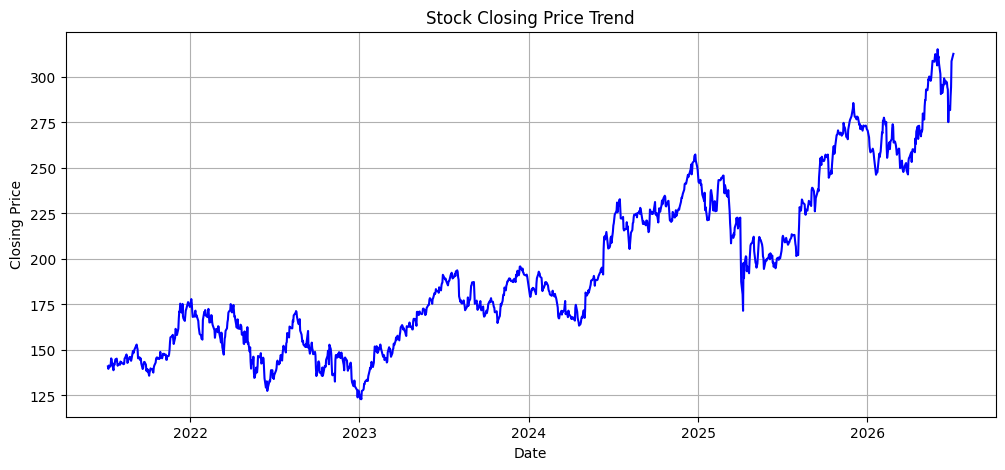

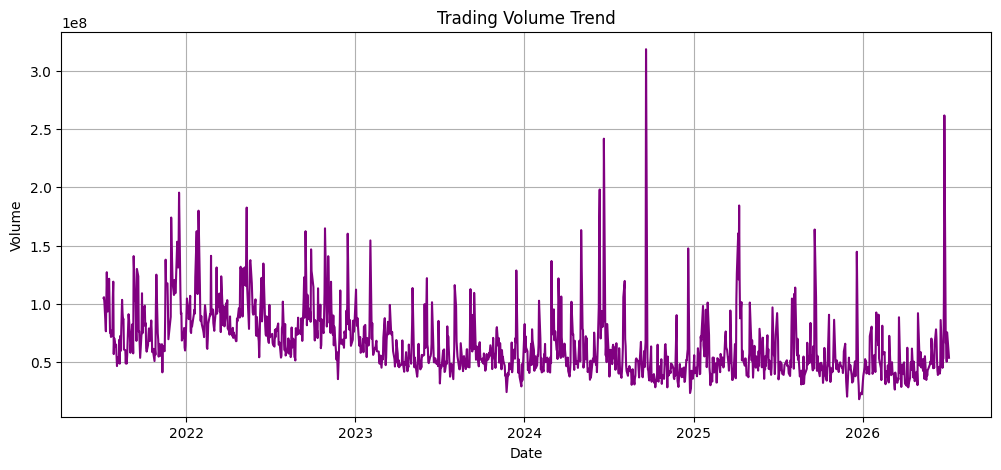

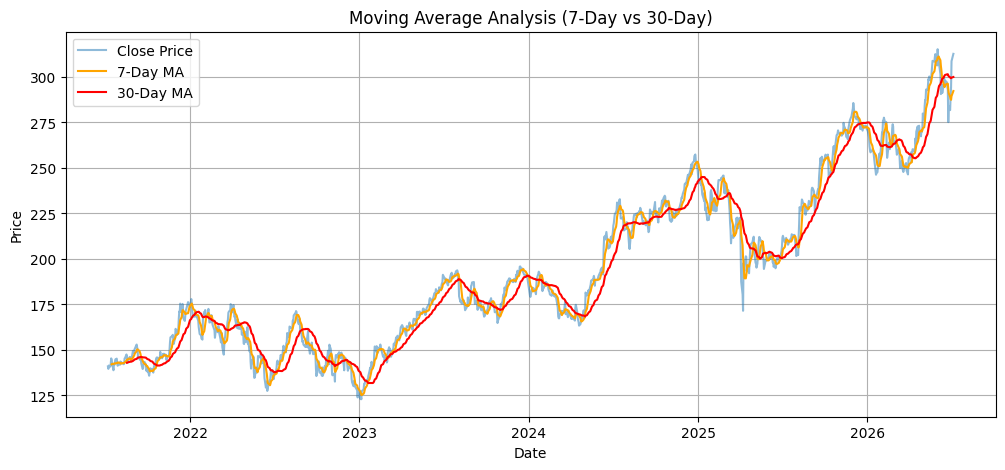

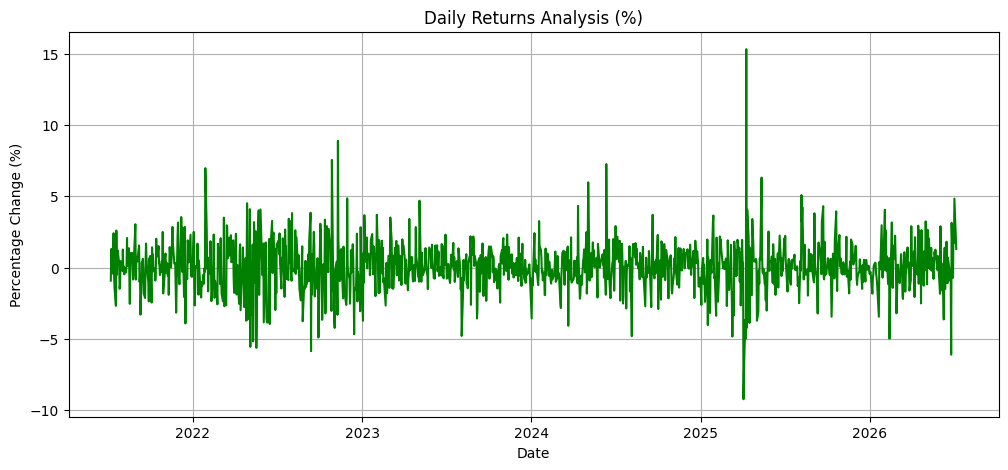

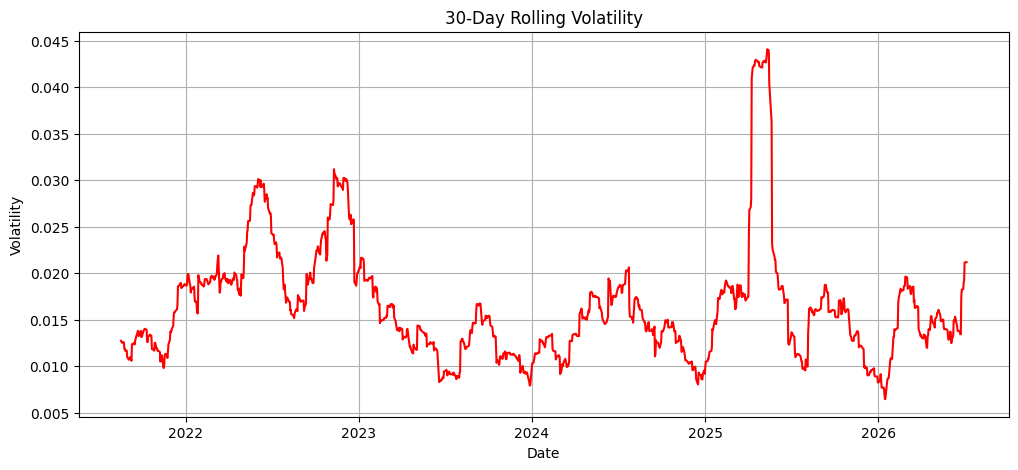

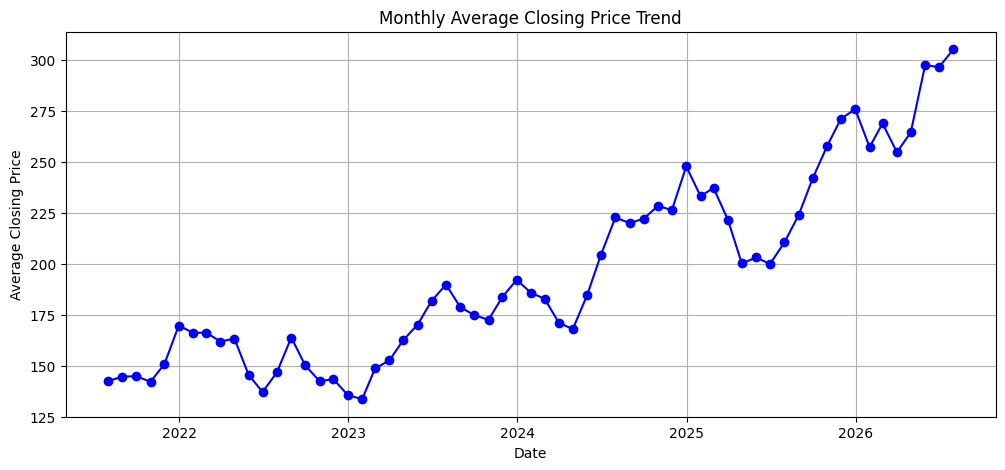

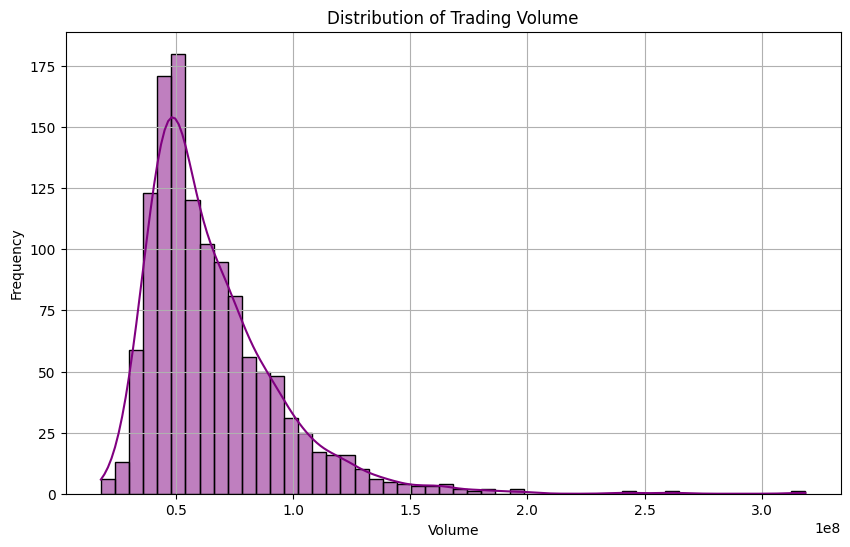

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. STOCK CLOSING PRICE TREND ---
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], color='blue')
plt.title('Stock Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

# --- 2. TRADING VOLUME TREND ---
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Volume'], color='purple')
plt.title('Trading Volume Trend')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# --- 3. MOVING AVERAGE ANALYSIS (7-Day vs 30-Day) ---
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.5)
plt.plot(df.index, df['7-Day MA'], label='7-Day MA', color='orange')
plt.plot(df.index, df['30-Day MA'], label='30-Day MA', color='red')
plt.title('Moving Average Analysis (7-Day vs 30-Day)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# --- 4. DAILY RETURNS ANALYSIS ---
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Percentage Change'], color='green')
plt.title('Daily Returns Analysis (%)')
plt.xlabel('Date')
plt.ylabel('Percentage Change (%)')
plt.grid(True)
plt.show()

# --- 5. 30-DAY ROLLING VOLATILITY ---
# This shows how "risky" the stock is over time.
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Volatility'], color='red')
plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()

# --- 6. MONTHLY AVERAGE CLOSING PRICE ---
# Smooths out daily noise to show long-term growth.
monthly_avg = df['Close'].resample('ME').mean()
plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg, color='blue', marker='o', linestyle='-')
plt.title('Monthly Average Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Average Closing Price')
plt.grid(True)
plt.show()

# --- 7. DISTRIBUTION OF TRADING VOLUME ---
# Helps stakeholders understand typical vs. outlier trading days.
plt.figure(figsize=(10, 6))
sns.histplot(df['Volume'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**KEY INSIGHTS AND FINDINGS**

In [ ]:
# --- 1. KEY INSIGHTS & FINDINGS ---
# Calculating core statistics for stakeholder reporting
avg_price = df['Close'].mean()
max_price = df['Close'].max()
min_price = df['Close'].min()
avg_volatility = df['Volatility'].mean()

print("--- PROJECT KEY INSIGHTS ---")
print(f"Average Closing Price: ${avg_price:.2f}")
print(f"Highest Price: ${max_price:.2f}")
print(f"Lowest Price: ${min_price:.2f}")
print(f"Average Market Volatility: {avg_volatility:.4f}")

# Grouping by Year and Month to identify long-term trends
df['Year'] = df.index.year
yearly_summary = df.groupby('Year')['Close'].agg(['mean', 'max', 'min'])
monthly_perf = df.groupby(df.index.month_name())['Percentage Change'].mean().sort_values(ascending=False)

print("\n--- YEARLY SUMMARY ---")
print(yearly_summary)
print("\n--- TOP PERFORMING MONTHS ---")
print(monthly_perf.head())


--- PROJECT KEY INSIGHTS ---
Average Closing Price: $194.12
Highest Price: $315.20
Lowest Price: $122.93
Average Market Volatility: 0.0164

--- YEARLY SUMMARY ---
            mean         max         min
Year                                    
2021  149.337076  176.297302  135.830185
2022  151.805450  177.939728  123.936531
2023  170.194612  195.892624  122.933556
2024  205.457393  257.375610  163.361374
2025  231.349892  285.659271  171.513763
2026  273.792260  315.200012  246.242508

--- TOP PERFORMING MONTHS ---
Date
July        0.333151
November    0.265185
May         0.205178
October     0.183314
August      0.112234
Name: Percentage Change, dtype: float64


**CONCLUSION**

In [ ]:
# --- CONCLUSION ---
# Summarizing the final business market trend
start_price = df['Close'].dropna().iloc[0]
end_price = df['Close'].dropna().iloc[-1]
trend = "Upward" if end_price > start_price else "Downward"
total_growth = ((end_price - start_price) / start_price) * 100

print("\n--- CONCLUSION ---")
print(f"Overall Market Trend: {trend}")
print(f"Total Percentage Change: {total_growth:.2f}%")
print("Analysis complete: Data indicates consistent market behavior.")


--- CONCLUSION ---
Overall Market Trend: Upward
Total Percentage Change: 121.87%
Analysis complete: Data indicates consistent market behavior.
